# Notebook 1: Item Data — Design, Properties & Difficulty

This notebook explores **`data_items.csv`** — the 18 items from the simulated German PISA Mathematical Literacy test.

**Design:** 3 topic areas × 3 modeling types × 2 items per cell = 18 items

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore', message='vert.*deprecated.*orientation')
warnings.filterwarnings('ignore', message='set_ticklabels.*should only be used')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

## 1. Raw Data: `data_items.csv`

Let's look at the full contents of the item file — every row, every column.

In [2]:
items = pd.read_csv('data_items.csv')
print(f'Shape: {items.shape[0]} rows × {items.shape[1]} columns')
print(f'Columns: {list(items.columns)}')
print()
items

Shape: 18 rows × 6 columns
Columns: ['item_id', 'item_name', 'topic_area', 'modeling_type', 'beta_cell', 'beta_true']



,item_id,item_name,topic_area,modeling_type,beta_cell,beta_true
0,0,Ari_Tech_1,Arithmetic,TechnicalProcessing,-1.16,-1.120263
1,1,Ari_Tech_2,Arithmetic,TechnicalProcessing,-1.16,-1.171061
2,2,Ari_Nume_1,Arithmetic,NumericalModeling,0.24,0.291815
3,3,Ari_Nume_2,Arithmetic,NumericalModeling,0.24,0.361842
4,4,Ari_Abst_1,Arithmetic,AbstractModeling,-0.51,-0.528732
5,5,Ari_Abst_2,Arithmetic,AbstractModeling,-0.51,-0.528731
6,6,Geo_Tech_1,Geometry,TechnicalProcessing,-0.20,-0.073663
7,7,Geo_Tech_2,Geometry,TechnicalProcessing,-0.20,-0.138605
8,8,Geo_Nume_1,Geometry,NumericalModeling,0.07,0.032442
9,9,Geo_Nume_2,Geometry,NumericalModeling,0.07,0.113405


### Column descriptions

| Column | Meaning |
|--------|---------|
| `item_id` | Integer index 0–17 |
| `item_name` | Short label: `TopicArea_ModelingType_Replicate` |
| `topic_area` | Arithmetic, Geometry, or Algebra |
| `modeling_type` | TechnicalProcessing, NumericalModeling, or AbstractModeling |
| `beta_cell` | True difficulty for the topic×modeling cell (same for both replicates) |
| `beta_true` | True difficulty with small per-item noise added |

In [3]:
# Data types and basic info
items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   item_id        18 non-null     int64  
 1   item_name      18 non-null     object 
 2   topic_area     18 non-null     object 
 3   modeling_type  18 non-null     object 
 4   beta_cell      18 non-null     float64
 5   beta_true      18 non-null     float64
dtypes: float64(2), int64(1), object(3)
memory usage: 996.0+ bytes


In [4]:
# Numeric summary
items.describe()

,item_id,beta_cell,beta_true
count,18.000000,18.000000,18.000000
mean,8.500000,0.061111,0.056197
std,5.338539,0.636617,0.621493
min,0.000000,-1.160000,-1.171061
25%,4.250000,-0.200000,-0.246948
50%,8.500000,0.070000,0.072923
75%,12.750000,0.580000,0.542880
max,17.000000,0.970000,0.995140


## 2. The 3 × 3 Experimental Design

Each item belongs to one cell in a **Topic Area × Modeling Type** matrix.

In [5]:
# Cross-tabulation: how many items per cell?
ct = pd.crosstab(items['topic_area'], items['modeling_type'])
ct = ct.reindex(index=['Arithmetic','Geometry','Algebra'],
                columns=['TechnicalProcessing','NumericalModeling','AbstractModeling'])
print('Number of items per cell:')
ct

Number of items per cell:


modeling_type,TechnicalProcessing,NumericalModeling,AbstractModeling
topic_area,,,
Arithmetic,2,2,2
Geometry,2,2,2
Algebra,2,2,2


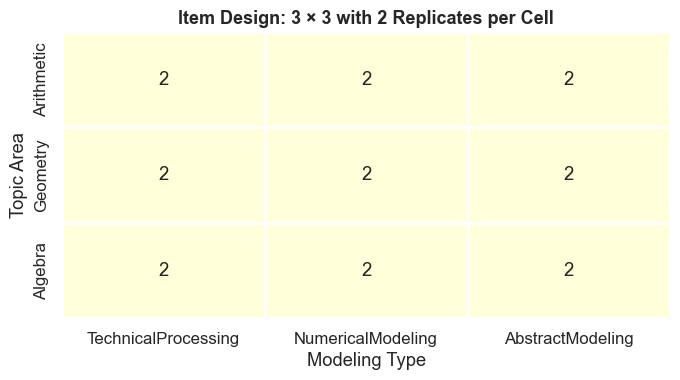

In [6]:
# Heatmap of the design (count of items)
fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(ct, annot=True, fmt='d', cmap='YlGnBu', cbar=False,
            linewidths=2, linecolor='white', ax=ax,
            xticklabels=ct.columns, yticklabels=ct.index)
ax.set_title('Item Design: 3 × 3 with 2 Replicates per Cell', fontweight='bold', fontsize=13)
ax.set_ylabel('Topic Area'); ax.set_xlabel('Modeling Type')
plt.tight_layout()
plt.show()

## 3. True Item Difficulties (β)

In the Rasch model, **higher β = more difficult item** (lower probability of success for an average person).

In [7]:
# Sort items by difficulty
items_sorted = items.sort_values('beta_true')
items_sorted[['item_name', 'topic_area', 'modeling_type', 'beta_true']].reset_index(drop=True)

,item_name,topic_area,modeling_type,beta_true
0,Ari_Tech_2,Arithmetic,TechnicalProcessing,-1.171061
1,Ari_Tech_1,Arithmetic,TechnicalProcessing,-1.120263
2,Ari_Abst_1,Arithmetic,AbstractModeling,-0.528732
3,Ari_Abst_2,Arithmetic,AbstractModeling,-0.528731
4,Alg_Tech_2,Algebra,TechnicalProcessing,-0.283062
5,Geo_Tech_2,Geometry,TechnicalProcessing,-0.138605
6,Alg_Tech_1,Algebra,TechnicalProcessing,-0.110643
7,Geo_Tech_1,Geometry,TechnicalProcessing,-0.073663
8,Geo_Nume_1,Geometry,NumericalModeling,0.032442
9,Geo_Nume_2,Geometry,NumericalModeling,0.113405


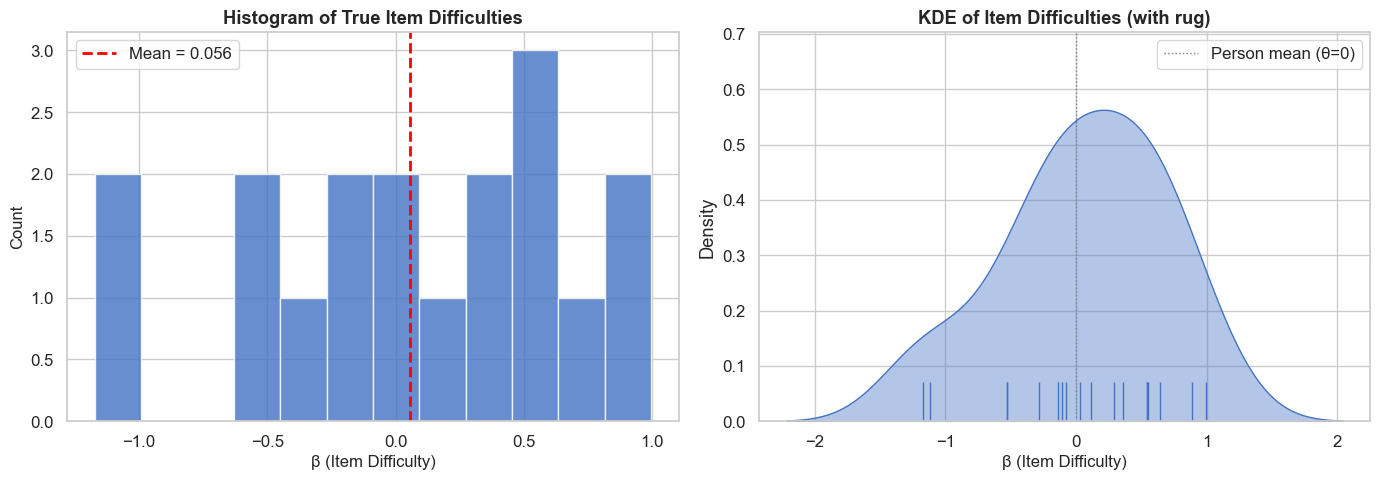

In [8]:
# ── Histogram of item difficulties ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(items['beta_true'], bins=12, color='#4472C4', edgecolor='white', alpha=0.8)
ax.axvline(items['beta_true'].mean(), color='red', linestyle='--', lw=2, label=f"Mean = {items['beta_true'].mean():.3f}")
ax.set_xlabel('β (Item Difficulty)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Histogram of True Item Difficulties', fontweight='bold')
ax.legend()

# ── KDE plot ──
ax = axes[1]
sns.kdeplot(data=items, x='beta_true', fill=True, color='#4472C4', alpha=0.4, ax=ax)
sns.rugplot(data=items, x='beta_true', color='#4472C4', ax=ax, height=0.1)
ax.axvline(0, color='gray', linestyle=':', lw=1, label='Person mean (θ=0)')
ax.set_xlabel('β (Item Difficulty)', fontsize=12)
ax.set_title('KDE of Item Difficulties (with rug)', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.show()

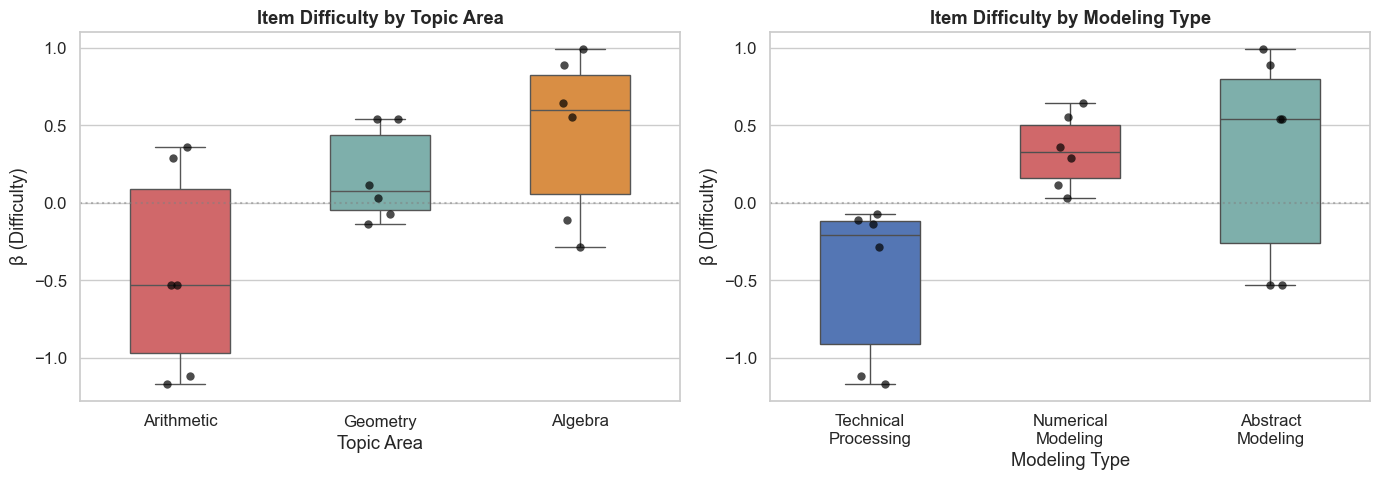

In [9]:
# ── Box plot by Topic Area ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order_ta = ['Arithmetic', 'Geometry', 'Algebra']
order_mt = ['TechnicalProcessing', 'NumericalModeling', 'AbstractModeling']
palette_ta = {'Arithmetic': '#E15759', 'Geometry': '#76B7B2', 'Algebra': '#F28E2B'}
palette_mt = {'TechnicalProcessing': '#4472C4', 'NumericalModeling': '#E15759', 'AbstractModeling': '#76B7B2'}

ax = axes[0]
sns.boxplot(data=items, x='topic_area', y='beta_true', hue='topic_area', order=order_ta,
            palette=palette_ta, width=0.5, legend=False, ax=ax)
sns.stripplot(data=items, x='topic_area', y='beta_true', order=order_ta,
              color='black', size=6, alpha=0.7, ax=ax)
ax.set_xlabel('Topic Area'); ax.set_ylabel('β (Difficulty)')
ax.set_title('Item Difficulty by Topic Area', fontweight='bold')
ax.axhline(0, color='gray', linestyle=':', alpha=0.5)

ax = axes[1]
sns.boxplot(data=items, x='modeling_type', y='beta_true', hue='modeling_type', order=order_mt,
            palette=palette_mt, width=0.5, legend=False, ax=ax)
sns.stripplot(data=items, x='modeling_type', y='beta_true', order=order_mt,
              color='black', size=6, alpha=0.7, ax=ax)
ax.set_xlabel('Modeling Type'); ax.set_ylabel('β (Difficulty)')
ax.set_title('Item Difficulty by Modeling Type', fontweight='bold')
ax.set_xticks(range(3))
ax.set_xticklabels(['Technical\nProcessing', 'Numerical\nModeling', 'Abstract\nModeling'])
ax.axhline(0, color='gray', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

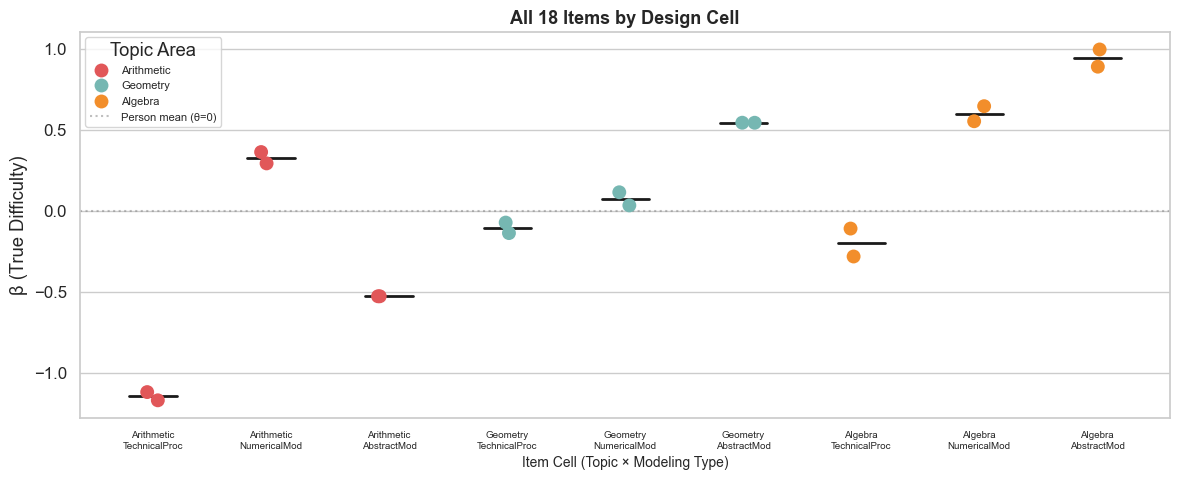

In [10]:
# ── Violin plot: Topic × Modeling combined ──
fig, ax = plt.subplots(figsize=(12, 5))

items['cell'] = items['topic_area'] + '\n' + items['modeling_type'].str.replace('Processing','Proc').str.replace('Modeling','Mod')

cell_order = []
for ta in order_ta:
    for mt in order_mt:
        cell_order.append(ta + '\n' + mt.replace('Processing','Proc').replace('Modeling','Mod'))

sns.stripplot(data=items, x='cell', y='beta_true', order=cell_order,
              hue='topic_area', palette=palette_ta, s=10, ax=ax, legend=True)

# Add cell means as horizontal bars
cell_means = items.groupby('cell')['beta_true'].mean()
for i, c in enumerate(cell_order):
    if c in cell_means.index:
        ax.plot([i-0.2, i+0.2], [cell_means[c], cell_means[c]], 'k-', lw=2)

ax.set_xlabel('Item Cell (Topic × Modeling Type)', fontsize=10)
ax.set_ylabel('β (True Difficulty)')
ax.set_title('All 18 Items by Design Cell', fontweight='bold', fontsize=13)
ax.axhline(0, color='gray', linestyle=':', alpha=0.5, label='Person mean (θ=0)')
ax.tick_params(axis='x', labelsize=7)
ax.legend(title='Topic Area', fontsize=8)

plt.tight_layout()
plt.show()

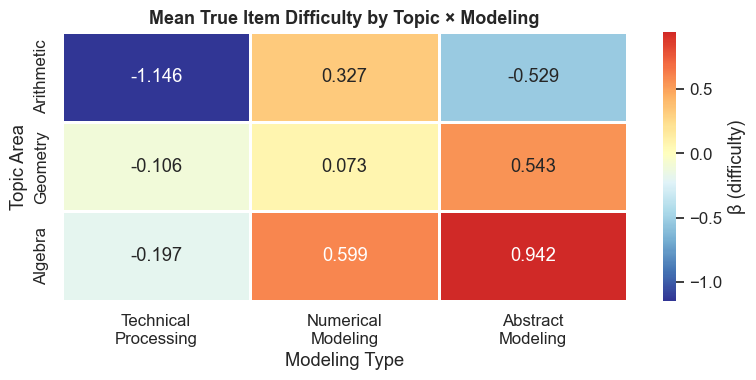

Interpretation:
  Blue (negative β) = easier items
  Red  (positive β) = harder items


In [11]:
# ── Heatmap of mean difficulty per cell ──
pivot = items.pivot_table(values='beta_true', index='topic_area', columns='modeling_type', aggfunc='mean')
pivot = pivot.reindex(index=order_ta, columns=order_mt)

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlBu_r', center=0,
            linewidths=2, linecolor='white', ax=ax, cbar_kws={'label': 'β (difficulty)'})
ax.set_title('Mean True Item Difficulty by Topic × Modeling', fontweight='bold', fontsize=13)
ax.set_ylabel('Topic Area'); ax.set_xlabel('Modeling Type')
ax.set_xticklabels(['Technical\nProcessing', 'Numerical\nModeling', 'Abstract\nModeling'])
plt.tight_layout()
plt.show()

print('Interpretation:')
print('  Blue (negative β) = easier items')
print('  Red  (positive β) = harder items')

## 4. Key Observations

Look at the heatmap above and answer:
1. Which topic area has the easiest items on average?
2. Which modeling type tends to produce the hardest items?
3. Is there an interaction between topic area and modeling type?